Loading model and generating embeddings...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

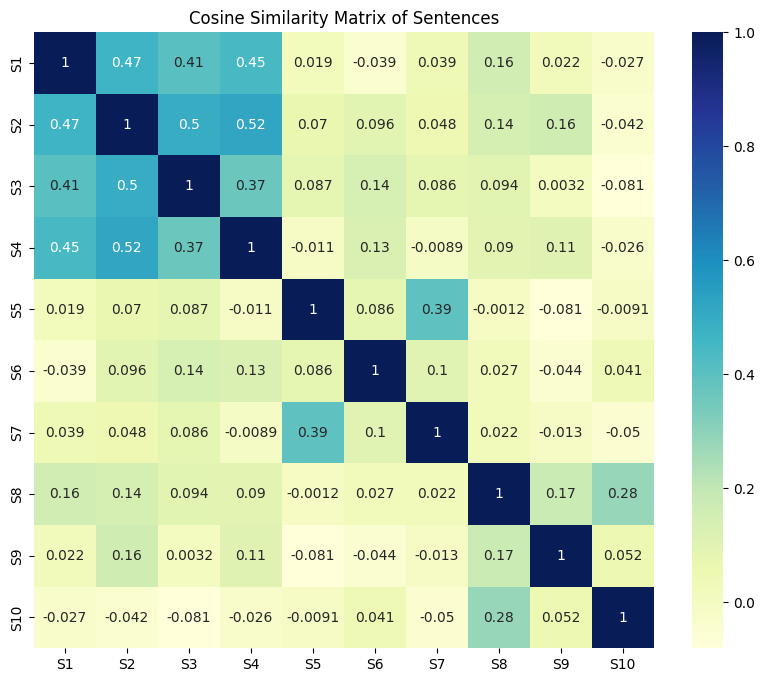


Query: 'The bowler took three wickets in one over'

Top 2 most similar sentences from the dataset:
- The spin bowler turned the ball sharply on the dusty pitch. (Similarity Score: 0.5809)
- The batsman hit a massive six over long-on to win the match. (Similarity Score: 0.5783)


In [ ]:
# Install the required libraries
!pip install sentence-transformers seaborn matplotlib pandas torch

from sentence_transformers import SentenceTransformer, util
import seaborn as sns
import matplotlib.pyplot as plt
import torch

# 1. Define 10 sentences across 3 topics (Cricket, Cooking, Cybersecurity)
sentences = [
    # Cricket
    "The batsman hit a massive six over long-on to win the match.",
    "Fast bowlers rely on swing and seam to deceive the opening batsmen.",
    "The spin bowler turned the ball sharply on the dusty pitch.",
    "Fielding restrictions in the first ten overs allow for aggressive batting.",
    # Cooking
    "Sauté the onions until they are golden brown and caramelized.",
    "Baking a perfect sourdough bread requires a healthy starter and precise temperature.",
    "Simmer the tomato sauce on low heat to let the flavors meld together.",
    # Cybersecurity
    "A zero-day vulnerability was exploited by hackers to breach the network.",
    "Multi-factor authentication adds an essential layer of security to user accounts.",
    "Ransomware encrypts critical files and demands payment in cryptocurrency."
]

# 2. Generate embeddings using the specified model
print("Loading model and generating embeddings...")
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences)

# 3. Compute and display a 10x10 cosine similarity matrix as a heatmap
cosine_scores = util.cos_sim(embeddings, embeddings)

plt.figure(figsize=(10, 8))
sns.heatmap(cosine_scores.numpy(), annot=True, cmap="YlGnBu",
            xticklabels=[f"S{i+1}" for i in range(10)],
            yticklabels=[f"S{i+1}" for i in range(10)])
plt.title("Cosine Similarity Matrix of Sentences")
plt.show()

# 4. Query sentence
query = "The bowler took three wickets in one over"
query_embedding = model.encode(query)

# Compute similarities against the query
query_scores = util.cos_sim(query_embedding, embeddings)[0]

# Find top 2 most similar sentences
top_results = torch.topk(query_scores, k=2)

print(f"\nQuery: '{query}'\n")
print("Top 2 most similar sentences from the dataset:")
for score, idx in zip(top_results[0], top_results[1]):
    print(f"- {sentences[idx]} (Similarity Score: {score:.4f})")